In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import scipy as sp
import scipy.ndimage
import json
import skimage.io

toppath = '/mpc/homes/fische_r/nanotom_data/2023_COELY_postmortem'
processing_dict_path = os.path.join(toppath, 'processing_data.json')

In [2]:
processing_dict = json.load(open(processing_dict_path,'r'))

In [3]:
# function to load nanotom vol file
# path = "/mnt/nas_nanotomData/CT_Data_PSI/FR54/2022_10_03_cell007_test_after_op/2022_10_03_cell007_test_after_op_.vol"   #the .vol file path

def load_nanotom(path, pcrSizeX = 0, pcrSizeY = 0, pcrSizeZ = 0):
    
    if pcrSizeX == 0 or pcrSizeY == 0 or pcrSizeZ == 0:
        print('searching pcr file for image dimensions')
    
        pcrpath = path.split('.')[0]+'.pcr'
        
        if not os.path.exists(pcrpath):
            print('pcr-file not found, please provide image dimensions manually')
        else:
            with open(pcrpath) as file:
                lines = file.readlines()
                
            for line in lines:
                splitline = line.split('=')
                if splitline[0] == 'ROI_SizeX':
                    pcrSizeX = int(splitline[1])
                if splitline[0] == 'ROI_SizeY':
                    pcrSizeY = int(splitline[1])
                if splitline[0] == 'ROI_SizeZ':
                    pcrSizeZ = int(splitline[1])
                    
    else:
        print('dimension manually provided as '+str(pcrSizeX)+'x'+str(pcrSizeY)+'x'+str(pcrSizeZ))
        
    print('dimensions considered as '+str(pcrSizeX)+'x'+str(pcrSizeY)+'x'+str(pcrSizeZ))
    
    print('load the file')
    
    with open(path,'r') as file:
        file.seek(0)
        im = np.fromfile(file, dtype='<f4').reshape(pcrSizeX,pcrSizeY,pcrSizeZ, order ='F')
        
    return im    

In [4]:
def testrotation(testim, angle):
    plt.figure(figsize=(12,12))
    testrot = sp.ndimage.rotate(testim, angle)
    plt.imshow(testrot, vmin=vmin, vmax=vmax)
    spacing = 25
    grid_0 = np.arange(0,testrot.shape[0],spacing)
    grid_1 = np.arange(0,testrot.shape[1],spacing)
    plt.hlines(grid_0, 0, testrot.shape[1]-1, 'w', linewidth = 0.5)
    plt.vlines(grid_1, 0, testrot.shape[0]-1, 'w', linewidth = 0.5)

In [5]:
def rotate_im(im, angle1, angle2, angle3):
    if np.abs(angle1)>0.25:
        im = sp.ndimage.rotate(im, angle1)
    if np.abs(angle2)>0.25:
        im = sp.ndimage.rotate(im, angle2, axes=(2,0))
    if np.abs(angle3)>0.25:
        im = sp.ndimage.rotate(im, angle3, axes=(2,1))
    return im

In [6]:
def create_grid(im,ax, spacing = 50):
    grid_0 = np.arange(0,im.shape[0]-spacing,spacing)
    grid_1 = np.arange(0,im.shape[1]-spacing,spacing)
    ax.hlines(grid_0, 0, im.shape[1]-1, 'w', linewidth = 0.5)
    ax.vlines(grid_1, 0, im.shape[0]-1, 'w', linewidth = 0.5)

In [7]:
vmin = -0.0587
vmax = 0.2144

In [8]:
series = 'Z'
sample = '4'

In [9]:
sample_path = os.path.join(toppath, series+'_series', series+'_'+sample)

In [11]:
preoppath = os.path.join(sample_path , series+'_'+sample+'_preop', series+'_'+sample+'_preop_.vol')
# preoppath = os.path.join(sample_path , series+sample+'_preop', series+sample+'_preop_.vol')
preopim = load_nanotom(preoppath)

searching pcr file for image dimensions
dimensions considered as 312x702x2398
load the file


In [12]:
postop1path = os.path.join(sample_path , series+'_'+sample+'_postop_1', series+'_'+sample+'_postop_1_.vol')
# postop1path = os.path.join(sample_path , series+'_2_postop1', series+'_2_postop1_.vol')
postop1im = load_nanotom(postop1path)

searching pcr file for image dimensions
dimensions considered as 295x743x2398
load the file


In [13]:
postop2path = os.path.join(sample_path, series+'_'+sample+'_postop_2', series+'_'+sample+'_postop_2_.vol')
postop2im = load_nanotom(postop2path)

searching pcr file for image dimensions
dimensions considered as 289x742x2397
load the file


In [102]:
im = postop2im 
stage = 'postop_2'
angle1 = 0
angle2 = -0.4
angle3 = 0.6

angles = {
    'preop': (-1 , -0.6 , -0.7), #(0,0,0)
    'postop_1': (0 , -0.6 , -0.7),
    'postop_2': (0 , -0.4 , 0.6)}
print(angle1,',',angle2,',',angle3)

0 , -0.4 , 0.6


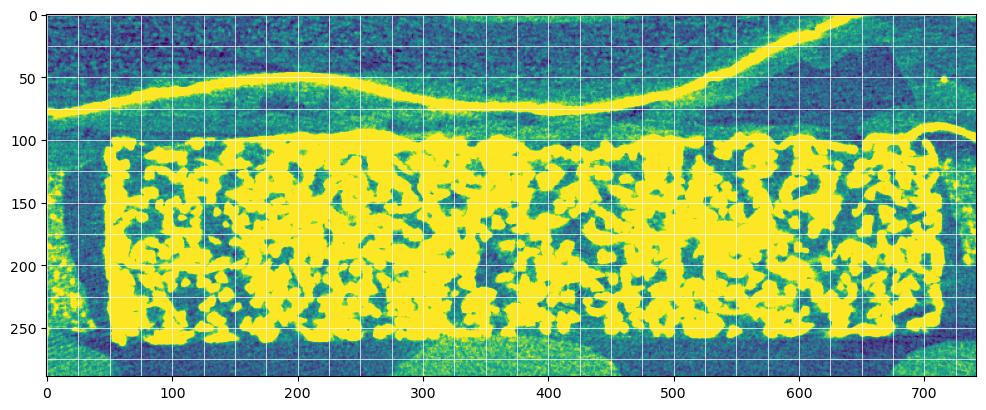

In [92]:
testrotation(im[:,:,1000], angle1)

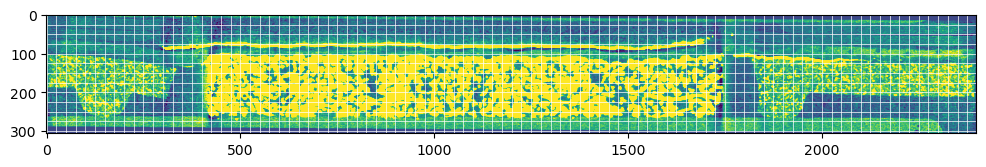

In [99]:
testrotation(im[:,400,:], angle2)

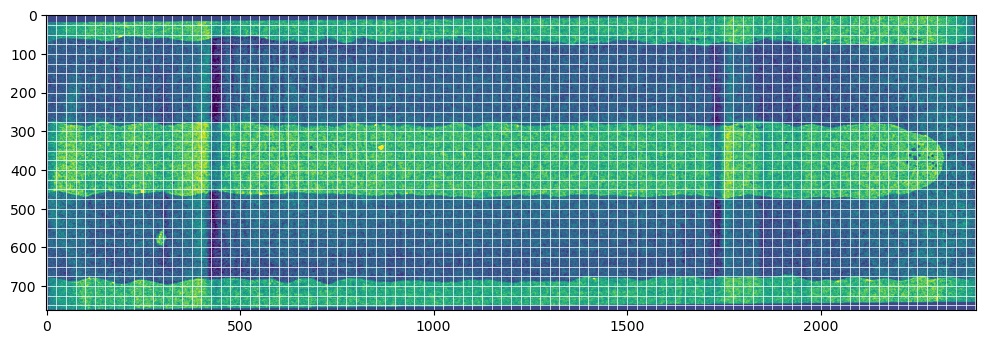

In [100]:
testrotation(im[280,:,:], angle3)

In [103]:
im = rotate_im(im, angle1, angle2, angle3)

In [119]:
crops = {
    'preop': (70 , 170 , 30 , 730 , 450 , 1750),   #0 , -1 , 0 , -1  , 0 , -1
    'postop_1': (55 , 155 , 40 , 740 , 500 , 1800),
    'postop_2': (50 , 150 , 30 , 730 , 400 , 1700)}

a,b,c,d,e,f = crops[stage]


a = 50
b = a+100
c = 30
d = c+700
e = 400
f = e + 1300

print(a,',',b,',',c,',',d,',',e,',',f)

50 , 150 , 30 , 730 , 400 , 1700


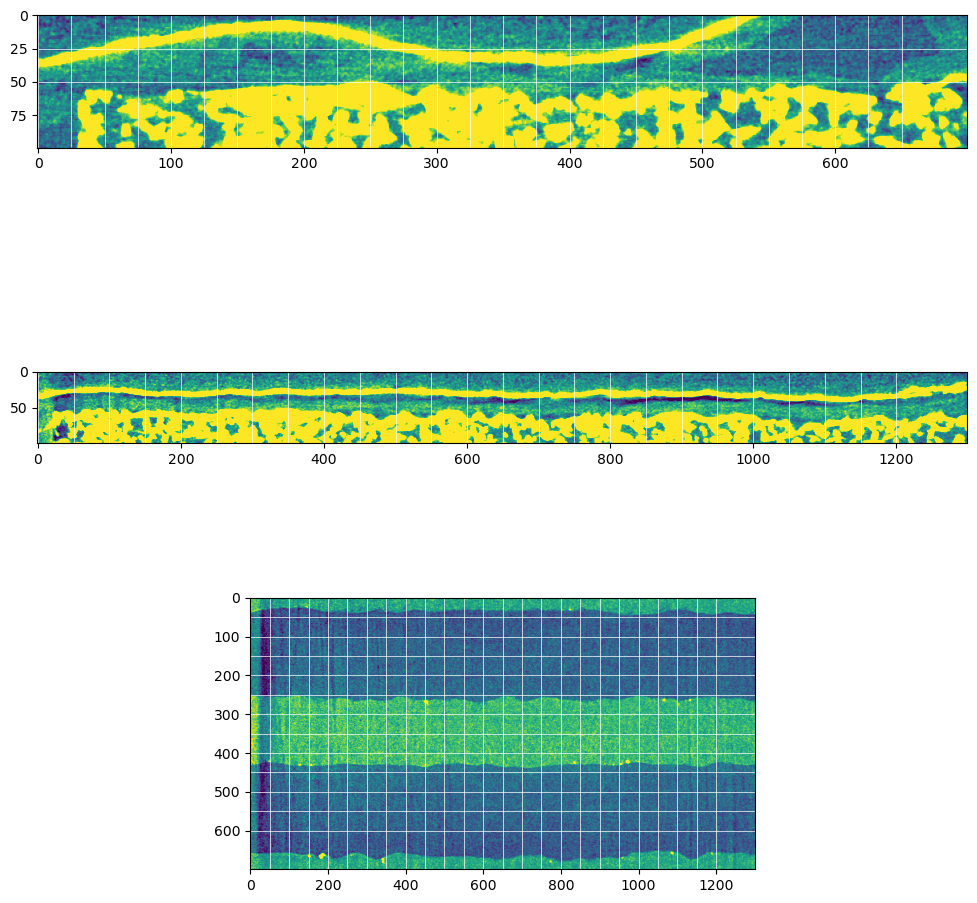

In [120]:
fig, axs = plt.subplots(3,1, figsize=(12,12))
im1 = im[a:b,c:d,1000]
im2 = im[a:b,400,e:f]
im3 = im[280,c:d,e:f]

axs[0].imshow(im1, vmin=vmin, vmax=vmax)
create_grid(im1,axs[0], spacing=25)
axs[1].imshow(im2, vmin=vmin, vmax=vmax)
create_grid(im2,axs[1])
axs[2].imshow(im3, vmin=vmin, vmax=vmax)
create_grid(im3,axs[2])


In [121]:
outim = im[a:b,c:d,e:f]

In [122]:
outputpath = os.path.join(sample_path, series+'_'+sample+'_'+stage+'_rotcrop.tif')
print(outputpath)

/mpc/homes/fische_r/nanotom_data/2023_COELY_postmortem/Z_series/Z_4/Z_4_postop_2_rotcrop.tif


In [123]:
skimage.io.imsave(outputpath,np.transpose(outim,(2,1,0)))

In [124]:
processing_dict[series+'_'+sample] = {'rotangles': angles,
                           'cropping': crops}

In [125]:
with open(processing_dict_path, "w") as outfile:
    json.dump(processing_dict, outfile,indent = 4)